# GAMEX Practical 2 — Conditional Normalising Flows for Edinburgh Airport Arrivals

**Edinburgh Summer School on Generative AI for Extremes — 8 September 2026**  
**Suggested time:** 30–35 minutes

This notebook models the **same synthetic Edinburgh Airport arrival trajectories** as the Transformer practical, but keeps every coordinate continuous.

Edinburgh Airport's single physical runway is **06/24**. Our simulator creates simplified arrivals from the appropriate side of the airport and makes them converge onto final approach.

These are **not real ADS-B tracks or published arrival procedures**.

Each flight contains 30 two-dimensional positions:

x = (x₁,y₁, …, x₃₀,y₃₀) ∈ ℝ⁶⁰.

We learn a conditional RealNVP map

x ↔ z,   z ∼ N(0,I),

with runway direction supplied as context.

The Transformer achieved tractability through **causal factorisation**.  
The normalising flow achieves it through **invertibility and change of variables**.


## Learning goals

By the end you should be able to:

- represent an entire aircraft approach as one continuous multivariate vector;
- standardise using training-set statistics only;
- fit a conditional multivariate-Gaussian baseline;
- implement an affine coupling layer from scratch;
- condition coupling networks on Runway 06 versus Runway 24;
- calculate the exact log-Jacobian determinant;
- train by maximum likelihood;
- test numerical invertibility before and after training;
- inspect latent Gaussianisation;
- generate complete continuous Edinburgh arrivals;
- evaluate route geometry and smoothness.


In [24]:
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 20260908
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.13.0+cu132
Device: cuda


## 1. Generate the same synthetic Edinburgh arrival distribution

Using exactly the same simulator lets us compare the two model families fairly.

The flow receives only the observed 16-waypoint trajectory and the runway condition. It is not given the simulator's latent entry offset, intercept distance or vectoring curvature.


In [27]:
# -------------------------------------------------------------------
# Synthetic Edinburgh Airport (EGPH) arrival simulator
# -------------------------------------------------------------------
#
# Real context used:
#   * Edinburgh has one physical runway, 06/24.
#   * Runway 06 arrivals approach from the west / south-west.
#   * Runway 24 arrivals approach from the east / north-east.
#
# Teaching assumptions:
#   * We generate simplified radar-vectoring-like turns onto final.
#   * These are NOT real ADS-B tracks, STARs, ILS procedures or ATC clearances.
#   * The simulator is designed only to create a realistic-looking
#     distribution for learning generative modelling.
#
# Local coordinate system:
#   x = East (km)
#   y = North (km)
#   airport/runway centre = (0, 0)

N_WAYPOINTS = 30
RUNWAY_LENGTH_KM = 2.56
HALF_RUNWAY_KM = RUNWAY_LENGTH_KM / 2

HEADING_06 = 60.0
HEADING_24 = 240.0

P_RUNWAY_24 = 0.85

AIRSPACE_XLIM = (-40.0, 40.0)
AIRSPACE_YLIM = (-30.0, 30.0)

def heading_vector(deg):
    rad = math.radians(deg)
    return torch.tensor(
        [math.sin(rad), math.cos(rad)],
        dtype=torch.float32,
    )

D06 = heading_vector(HEADING_06)
D24 = heading_vector(HEADING_24)

CROSS = torch.tensor([D06[1], -D06[0]])

THRESHOLD_06 = -HALF_RUNWAY_KM * D06
THRESHOLD_24 = +HALF_RUNWAY_KM * D06

def smoothstep(q):
    q = torch.clamp(q, 0.0, 1.0)
    return q * q * (3.0 - 2.0 * q)

def make_edinburgh_arrivals(
    n_flights=4000,
    n_waypoints=N_WAYPOINTS,
    seed=SEED,
):
    g = torch.Generator().manual_seed(seed)

    trajectories = []
    runway_labels = []
    altitudes = []

    for _ in range(n_flights):
        runway = int(
            (torch.rand((), generator=g) < P_RUNWAY_24).item()
        )

        if runway == 0:
            heading = D06
            threshold = THRESHOLD_06
        else:
            heading = D24
            threshold = THRESHOLD_24

        start_distance = 28.0 + 10.0 * torch.rand((), generator=g)
        intercept_distance = 9.0 + 5.0 * torch.rand((), generator=g)

        initial_cross_track = 6.0 * torch.randn((), generator=g)
        vectoring_bend = 2.2 * torch.randn((), generator=g)
        intercept_cross_track = 0.35 * torch.randn((), generator=g)
        touchdown_cross_track = 0.05 * torch.randn((), generator=g)

        distance_to_threshold = torch.linspace(
            start_distance.item(),
            0.0,
            n_waypoints,
        )

        cross_track = torch.zeros(n_waypoints)

        for j, d in enumerate(distance_to_threshold):
            if d > intercept_distance:
                q = (d - intercept_distance) / (
                    start_distance - intercept_distance
                )
                q = torch.clamp(q, 0.0, 1.0)

                cross_track[j] = (
                    intercept_cross_track
                    + (initial_cross_track - intercept_cross_track)
                    * smoothstep(q)
                    + vectoring_bend * torch.sin(math.pi * q)
                )
            else:
                q = d / intercept_distance
                cross_track[j] = (
                    touchdown_cross_track
                    + (intercept_cross_track - touchdown_cross_track) * q
                )

        envelope = (distance_to_threshold / start_distance) ** 1.5
        cross_track += (
            0.12
            * torch.randn(n_waypoints, generator=g)
            * envelope
        )

        xy = (
            threshold[None, :]
            - distance_to_threshold[:, None] * heading[None, :]
            + cross_track[:, None] * CROSS[None, :]
        )

        xy[-1] = threshold + touchdown_cross_track * CROSS

        altitude = (
            0.06
            + 0.055 * distance_to_threshold
            + 0.05
            * torch.randn(n_waypoints, generator=g)
            * envelope
        )
        altitude = torch.clamp(altitude, min=0.05)

        trajectories.append(xy)
        runway_labels.append(runway)
        altitudes.append(altitude)

    return (
        torch.stack(trajectories),
        torch.tensor(runway_labels).long(),
        torch.stack(altitudes),
    )

def draw_edinburgh_runway(ax=None, show_extended_final=False):
    if ax is None:
        ax = plt.gca()

    a = -HALF_RUNWAY_KM * D06
    b = +HALF_RUNWAY_KM * D06

    ax.plot(
        [a[0], b[0]],
        [a[1], b[1]],
        linewidth=6,
        solid_capstyle="butt",
        label="Edinburgh Airport Runway",
    )

    ax.scatter(
        [THRESHOLD_06[0], THRESHOLD_24[0]],
        [THRESHOLD_06[1], THRESHOLD_24[1]],
        marker="|",
        s=140,
    )

    if show_extended_final:
        for threshold, heading in [
            (THRESHOLD_06, D06),
            (THRESHOLD_24, D24),
        ]:
            outer = threshold - 15.0 * heading
            ax.plot(
                [threshold[0], outer[0]],
                [threshold[1], outer[1]],
                linestyle="--",
                linewidth=1, color="steelblue"
            )

def project_to_runway_coordinates(xy, runway_value):
    if runway_value == 0:
        heading = D06
        threshold = THRESHOLD_06
    else:
        heading = D24
        threshold = THRESHOLD_24

    relative = xy - threshold
    distance_to_threshold = -(relative @ heading)
    cross_track = relative @ CROSS

    return distance_to_threshold, cross_track

trajectories, runway, altitude = make_edinburgh_arrivals()

print("Dataset:", tuple(trajectories.shape))
print("RWY 06 flights:", int((runway == 0).sum()))
print("RWY 24 flights:", int((runway == 1).sum()))
print("RWY 24 fraction:", round((runway == 1).float().mean().item(), 3))


Dataset: (4000, 30, 2)
RWY 06 flights: 603
RWY 24 flights: 3397
RWY 24 fraction: 0.849


### What is real and what is synthetic?

**Real contextualisation:** Edinburgh Airport, runway 06/24, opposite approach directions.

**Synthetic teaching design:** outer-airspace spread, vectoring curvature, intercept distance and noise.

The goal is not to reproduce ATC procedures. The goal is to create a structured continuous probability distribution with intuitive geometry.


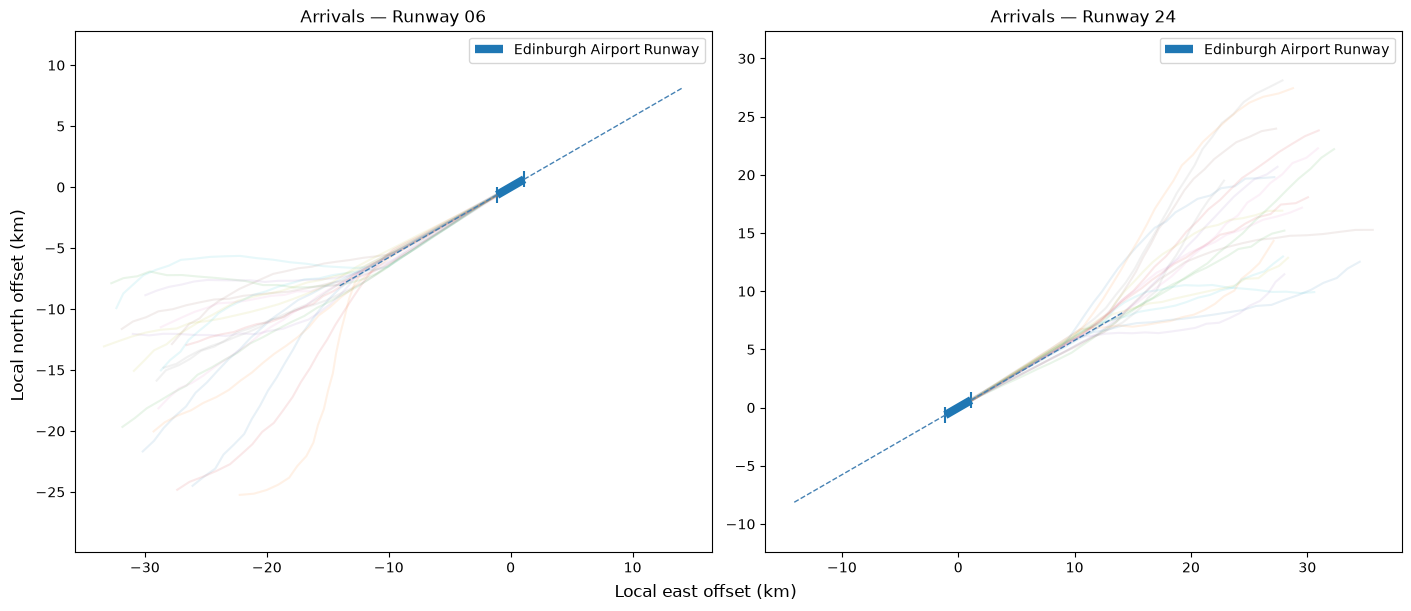

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, (runway_value, label) in zip(
    axes,
    [(0, "06"), (1, "24")],
):
    for traj in trajectories[runway == runway_value][20:40]:
        ax.plot(traj[:, 0], traj[:, 1], alpha=0.10)

    draw_edinburgh_runway(ax=ax, show_extended_final=True)
    ax.set_title(f"Arrivals — Runway {label}")
    ax.set_xlim(*AIRSPACE_XLIM)
    ax.set_ylim(*AIRSPACE_YLIM)
    ax.axis("equal")
    ax.legend()
fig.supxlabel("Local east offset (km)")
fig.supylabel("Local north offset (km)")
plt.show()


## 2. Runway-aligned diagnostic

Before building the flow, inspect the distribution in coordinates aligned with the runway.

The cross-track spread should be broad far from the airport and narrow substantially close to touchdown.


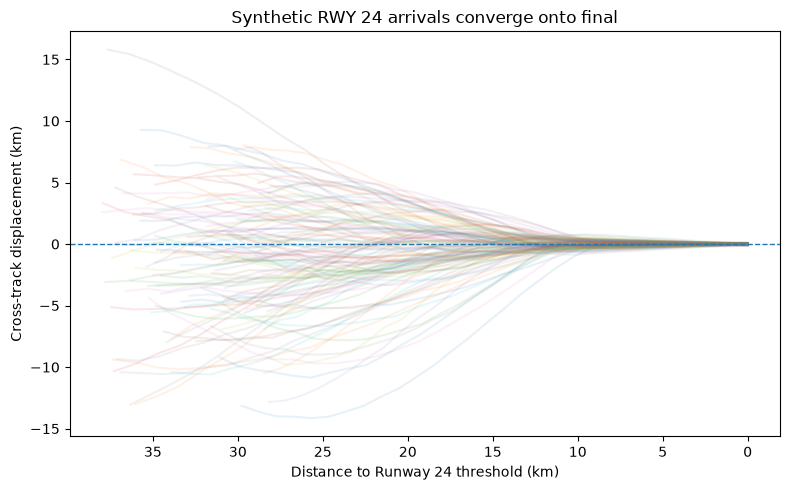

In [4]:
plt.figure(figsize=(8, 5))

for traj in trajectories[runway == 1][:120]:
    distance, cross = project_to_runway_coordinates(
        traj,
        runway_value=1,
    )
    plt.plot(distance, cross, alpha=0.10)

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.gca().invert_xaxis()

plt.xlabel("Distance to Runway 24 threshold (km)")
plt.ylabel("Cross-track displacement (km)")
plt.title("Synthetic RWY 24 arrivals converge onto final")
plt.tight_layout()
plt.show()


## 3. Flatten and standardise

The 30 `(x,y)` waypoint pairs become one 60-dimensional vector.

Standardisation statistics are estimated from the training set only and stored for later inversion.


In [29]:
flat = trajectories.reshape(len(trajectories), -1)

DIMENSION = flat.shape[1]

n = len(flat)
perm = torch.randperm(
    n,
    generator=torch.Generator().manual_seed(SEED),
)

n_train = int(0.80 * n)
n_val = int(0.10 * n)

idx_train = perm[:n_train]
idx_val = perm[n_train:n_train + n_val]
idx_test = perm[n_train + n_val:]

x_train_raw = flat[idx_train]
c_train = runway[idx_train]

x_val_raw = flat[idx_val]
c_val = runway[idx_val]

x_test_raw = flat[idx_test]
c_test = runway[idx_test]

train_mean = x_train_raw.mean(dim=0)
train_std = x_train_raw.std(dim=0).clamp_min(0.05)

def standardise(x):
    return (x - train_mean) / train_std

def unstandardise(x):
    return x * train_std + train_mean

x_train = standardise(x_train_raw)
x_val = standardise(x_val_raw)
x_test = standardise(x_test_raw)

BATCH_SIZE = 256

train_loader = DataLoader(
    TensorDataset(x_train, c_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    TensorDataset(x_val, c_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    TensorDataset(x_test, c_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Flow dimension:", DIMENSION)
print("Train/validation/test:", len(x_train), len(x_val), len(x_test))


Flow dimension: 60
Train/validation/test: 3200 400 400


### Why the first affine flow struggled

This synthetic dataset is visually simple but statistically difficult for a small exact-density model: the 60 coordinates are extremely correlated and lie close to a thin manifold.

- The full-covariance Gaussian is therefore a strong baseline because it captures the dominant linear dependence directly.
- With flattened ordering `(x₁,y₁,x₂,y₂,...)`, the original even/odd masks are effectively an **East-versus-North split**, so six layers provide limited mixing.
- With six layers and `scale_limit = 1.2`, each coordinate is directly rescaled only three times. That is not enough for some very low-variance directions.
- Pure maximum likelihood can over-squeeze an almost singular dataset. A model can obtain a better NLL but have an unstable inverse map and poor samples.

The diagnostic below quantifies how concentrated the condition-wise covariance is.

In [6]:
def covariance_spectrum(x):
    centred = x - x.mean(dim=0, keepdim=True)
    covariance = centred.T @ centred / (len(x) - 1)
    return torch.linalg.eigvalsh(covariance)

for condition, label in [(0, "06"), (1, "24")]:
    xc = x_train[c_train == condition]
    eigvals = covariance_spectrum(xc)

    print(
        f"RWY {label}: {len(xc)} training flights | "
        f"eigenvalues > 1e-4: {(eigvals > 1e-4).sum().item():2d}/{DIMENSION} | "
        f"largest eigenvalue: {eigvals.max().item():.3f}"
    )

print()
print(
    "Original even/odd masking on (x1,y1,x2,y2,...) "
    "separates East and North coordinates rather than mixing waypoints."
)

RWY 06: 419 training flights | eigenvalues > 1e-4:  9/60 | largest eigenvalue: 1.996
RWY 24: 2381 training flights | eigenvalues > 1e-4:  9/60 | largest eigenvalue: 2.117

Original even/odd masking on (x1,y1,x2,y2,...) separates East and North coordinates rather than mixing waypoints.


## 4. Conditional Gaussian baseline

A full-covariance Gaussian for each runway is meaningful because it captures the mean arrival shape, marginal variability at every waypoint and linear dependence among all 32 coordinates.

The flow must justify its additional flexibility by fitting non-Gaussian structure better.


In [7]:
def empirical_covariance(x):
    centred = x - x.mean(dim=0, keepdim=True)
    return centred.T @ centred / (len(x) - 1)

gaussian_models = {}

for condition in [0, 1]:
    xc = x_train[c_train == condition]

    mean = xc.mean(dim=0)
    covariance = empirical_covariance(xc)
    covariance += 2e-3 * torch.eye(DIMENSION)

    gaussian_models[condition] = (
        torch.distributions.MultivariateNormal(
            mean,
            covariance_matrix=covariance,
        )
    )

def conditional_gaussian_nll(x, c):
    log_prob = torch.empty(len(x))

    for condition in [0, 1]:
        mask = c == condition

        if mask.any():
            log_prob[mask] = (
                gaussian_models[condition]
                .log_prob(x[mask])
            )

    return -log_prob.mean().item()

gaussian_test_nll = conditional_gaussian_nll(
    x_test,
    c_test,
)

print("Conditional Gaussian test NLL:", round(gaussian_test_nll, 3))


Conditional Gaussian test NLL: -115.384


## 5. Conditional affine coupling

We keep the same RealNVP architecture: one subset of coordinates stays fixed while an affine transformation is applied to the rest.

The changes are still within the affine-coupling design:

- balanced fixed masks mix East/North coordinates and different waypoints;
- `SiLU` gives a smoother conditioner;
- scale remains bounded;
- shift is also bounded to reduce extreme inverse extrapolation.

The layer is still exactly invertible and its log-Jacobian determinant is still cheap.

In [ ]:
def make_balanced_masks(
    dimension,
    n_layers,
    seed=SEED + 99,
):
    """Create fixed mask/complement pairs with coordinate mixing."""
    g = torch.Generator().manual_seed(seed)
    masks = []

    for _ in range((n_layers + 1) // 2):
        perm = torch.randperm(dimension, generator=g)
        mask = torch.zeros(dimension)
        mask[perm[: dimension // 2]] = 1.0
        masks.append(mask)

        if len(masks) < n_layers:
            masks.append(1.0 - mask)

    return masks[:n_layers]


class ConditionalAffineCoupling(nn.Module):
    def __init__(
        self,
        dimension,
        mask,
        hidden_dim=128,
        condition_dim=2,
        scale_limit=1.2,
        shift_limit=3.0,
    ):
        super().__init__()

        self.register_buffer("mask", mask.float())
        self.condition_dim = condition_dim
        self.scale_limit = float(scale_limit)
        self.shift_limit = float(shift_limit)

        self.net = nn.Sequential(
            nn.Linear(dimension + condition_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2 * dimension))

        # Start close to the identity transformation.
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def _scale_shift(self, fixed_x, condition):
        context = F.one_hot(
            condition.long(),
            num_classes=self.condition_dim,
        ).float()

        h = torch.cat([fixed_x, context], dim=1)

        raw_scale, raw_shift = self.net(h).chunk(2, dim=1)
        transformed = 1.0 - self.mask

        scale = (
            self.scale_limit
            * torch.tanh(raw_scale)
            * transformed
        )

        shift = (
            self.shift_limit
            * torch.tanh(raw_shift / self.shift_limit)
            * transformed
        )

        return scale, shift

    def forward(self, x, condition):
        fixed_x = x * self.mask
        scale, shift = self._scale_shift(fixed_x, condition)

        y = (
            fixed_x
            + (1.0 - self.mask)
            * (x * torch.exp(scale) + shift)
        )

        return y, scale.sum(dim=1)

    def inverse(self, y, condition):
        fixed_y = y * self.mask
        scale, shift = self._scale_shift(fixed_y, condition)

        x = (
            fixed_y
            + (1.0 - self.mask)
            * ((y - shift) * torch.exp(-scale))
        )

        return x, -scale.sum(dim=1)

## 6. Invertibility test before training

This is a software unit test for the defining mathematical property of the flow.

Do not proceed if the round-trip error is not close to floating-point precision.


In [30]:
test_layer = ConditionalAffineCoupling(
    DIMENSION,
    make_balanced_masks(DIMENSION, 1)[0],
).to(device)

probe_x = torch.randn(128, DIMENSION, device=device)
probe_c = torch.randint(0, 2, (128,), device=device)

with torch.inference_mode():
    y, ld = test_layer(probe_x, probe_c)
    x_back, ild = test_layer.inverse(y, probe_c)

reconstruction_error = (
    probe_x - x_back
).abs().max().item()

logdet_error = (
    ld + ild
).abs().max().item()

print(
    "One-layer reconstruction error:",
    f"{reconstruction_error:.7f}",
)
print(
    "One-layer log-det error:",
    f"{logdet_error:.7f}",
)

assert reconstruction_error < 1e-5
assert logdet_error < 1e-5


One-layer reconstruction error: 0.0000000
One-layer log-det error: 0.0000000


## 7. Stack coupling layers into a conditional RealNVP

The learned model is still only a stack of affine coupling layers.

We increase the depth from 6 to 12 and use fixed balanced mask/complement pairs. Every coordinate is transformed once per pair, while the mixed masks avoid repeatedly separating all East coordinates from all North coordinates.

In [10]:
class EdinburghArrivalRealNVP(nn.Module):
    def __init__(
        self,
        dimension=DIMENSION,
        n_layers=10,
        hidden_dim=64,
        condition_dim=2,
        scale_limit=1.2,
        shift_limit=3.0,
    ):
        super().__init__()

        masks = make_balanced_masks(
            dimension,
            n_layers,
        )

        self.layers = nn.ModuleList([
            ConditionalAffineCoupling(
                dimension=dimension,
                mask=mask,
                hidden_dim=hidden_dim,
                condition_dim=condition_dim,
                scale_limit=scale_limit,
                shift_limit=shift_limit,
            )
            for mask in masks
        ])

    def forward(self, x, condition):
        z = x

        total_logdet = torch.zeros(
            len(x),
            device=x.device,
        )

        for layer in self.layers:
            z, logdet = layer(z, condition)
            total_logdet += logdet

        return z, total_logdet

    def inverse(self, z, condition):
        x = z

        total_inverse_logdet = torch.zeros(
            len(z),
            device=z.device,
        )

        for layer in reversed(self.layers):
            x, logdet = layer.inverse(
                x,
                condition,
            )
            total_inverse_logdet += logdet

        return x, total_inverse_logdet


flow = EdinburghArrivalRealNVP().to(device)

print(
    "Trainable parameters:",
    f"{sum(p.numel() for p in flow.parameters()):,}",
)

Trainable parameters: 159,920


In [11]:
probe_x = torch.randn(128, DIMENSION, device=device)
probe_c = torch.randint(0, 2, (128,), device=device)

with torch.inference_mode():
    z, ld = flow(probe_x, probe_c)
    x_back, ild = flow.inverse(z, probe_c)

roundtrip = (probe_x - x_back).abs().max().item()
logdet_consistency = (ld + ild).abs().max().item()

print("Full-flow round-trip:", f"{roundtrip:.2e}")
print("Full-flow log-det error:", f"{logdet_consistency:.2e}")

assert roundtrip < 1e-5
assert logdet_consistency < 1e-5


Full-flow round-trip: 0.00e+00
Full-flow log-det error: 0.00e+00


## 8. Exact log-likelihood by change of variables

For a trajectory x and runway c,

log p(x | c)
=
log p_Z(f(x,c))
+
log |det J_f(x,c)|.

The base density is a 32-dimensional standard Gaussian.


## 9. Train by maximum likelihood, with light density regularisation

The objective is still flow negative log-likelihood.

We add Gaussian noise with standard deviation `0.02` **after standardisation and only during training**. The simulator otherwise produces an almost singular density, so unregularised maximum likelihood can reward extreme contraction around the trajectory manifold and damage sampling.

Validation and test NLL are evaluated on the clean held-out trajectories. We also train longer, reduce the learning rate when validation stalls, and restore the best validation checkpoint.

In [ ]:
LOG_2PI = math.log(2.0 * math.pi)

def standard_normal_log_prob(z):
    return -0.5 * (z.pow(2) + LOG_2PI).sum(dim=1)

def flow_log_prob(model, x, condition):
    z, logdet = model(x, condition)
    return (standard_normal_log_prob(z) + logdet)

def flow_nll(model, x, condition):
    return -flow_log_prob(model, x, condition).mean()

def evaluate_flow_nll(model, loader):
    model.eval()

    total = 0.0
    count = 0

    with torch.inference_mode():
        for x, condition in loader:
            x = x.to(device)
            condition = condition.to(device)
            log_prob = flow_log_prob(model, x, condition)

            total += (-log_prob).sum().item()
            count += len(x)

    return total / count

optimizer = torch.optim.AdamW(
    flow.parameters(),
    lr=5e-3,
    weight_decay=1e-4)

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode="min",
#     factor=0.5,
#     patience=7,
#     min_lr=5e-5,
# )

N_EPOCHS = 70

history = {
    "train_nll": [],
    "val_nll": [],
}

# train_noise_generator = torch.Generator().manual_seed(
#     SEED + 1
# )

best_val_nll = float("inf")
best_epoch = None
best_state = None

for epoch in range(1, N_EPOCHS + 1):
    flow.train()

    total = 0.0
    count = 0

    for x, condition in train_loader:
        # noise = TRAIN_NOISE_STD * torch.randn(x.shape, generator=train_noise_generator)
        # x = (x + noise).to(device)
        x = x.to(device)
        condition = condition.to(device)

        optimizer.zero_grad()

        loss = flow_nll(flow, x, condition)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)
        optimizer.step()

        total += loss.item() * len(x)
        count += len(x)

    train_nll = total / count
    val_nll = evaluate_flow_nll(flow, val_loader)

    # scheduler.step(val_nll)

    history["train_nll"].append(train_nll)
    history["val_nll"].append(val_nll)

    if val_nll < best_val_nll:
        best_val_nll = val_nll
        best_epoch = epoch
        best_state = {
            key: value.detach().cpu().clone()
            for key, value in flow.state_dict().items()
        }

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"train NLL {train_nll:.3f} | "
            f"val NLL {val_nll:.3f}"
            # f"lr {optimizer.param_groups[0]['lr']:.7f}"
        )

flow.load_state_dict(best_state)
print(f"Restored epoch {best_epoch} ", f"with best validation NLL {best_val_nll:.3f}")

Epoch 01 | train NLL 165.044 | val NLL -30.957 | lr 0.0075000
Epoch 05 | train NLL -152.522 | val NLL -161.743 | lr 0.0075000
Epoch 10 | train NLL -193.097 | val NLL -196.509 | lr 0.0075000
Epoch 15 | train NLL -200.672 | val NLL -193.968 | lr 0.0075000
Epoch 20 | train NLL -203.418 | val NLL -204.430 | lr 0.0075000
Epoch 25 | train NLL -206.211 | val NLL -195.595 | lr 0.0075000
Epoch 30 | train NLL -201.477 | val NLL -203.469 | lr 0.0075000
Epoch 35 | train NLL -206.093 | val NLL -201.033 | lr 0.0075000
Epoch 40 | train NLL -211.319 | val NLL -215.365 | lr 0.0075000
Epoch 45 | train NLL -204.101 | val NLL -198.674 | lr 0.0075000
Epoch 50 | train NLL -210.740 | val NLL -213.362 | lr 0.0075000
Epoch 55 | train NLL -204.748 | val NLL -204.575 | lr 0.0075000
Epoch 60 | train NLL -207.133 | val NLL -205.974 | lr 0.0075000
Epoch 65 | train NLL -208.955 | val NLL -209.218 | lr 0.0075000
Epoch 70 | train NLL -202.538 | val NLL -203.310 | lr 0.0075000

Restored epoch 40 with best validation NL

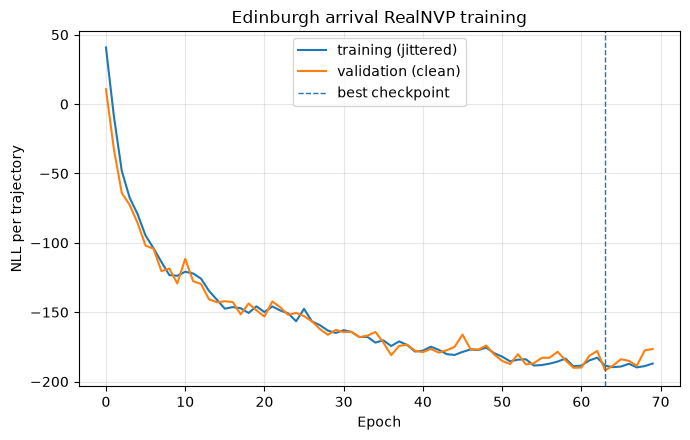

Conditional Gaussian test NLL: -115.384
Conditional flow test NLL: -193.75
Flow improvement over Gaussian: 78.366

Per-runway held-out NLL
RWY 06: Gaussian -115.270 | Flow -125.964
RWY 24: Gaussian -115.404 | Flow -205.401


In [ ]:
plt.figure(figsize=(7, 4.5))
plt.plot(
    history["train_nll"],
    label="training (jittered)",
)
plt.plot(
    history["val_nll"],
    label="validation (clean)",
)
plt.axvline(
    best_epoch - 1,
    linestyle="--",
    linewidth=1,
    label="best checkpoint",
)
plt.xlabel("Epoch")
plt.ylabel("NLL per trajectory")
plt.title("Training and validation loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

flow_test_nll = evaluate_flow_nll(
    flow,
    test_loader,
)

print("Conditional Gaussian test NLL:", round(gaussian_test_nll, 3))
print("Conditional flow test NLL:", round(flow_test_nll, 3))
print("Flow improvement over Gaussian:", round(gaussian_test_nll - flow_test_nll, 3))
print("Per-runway held-out NLL")

for condition, label in [(0, "06"), (1, "24")]:
    mask = c_test == condition

    gaussian_nll = -(
        gaussian_models[condition]
        .log_prob(x_test[mask])
        .mean()
        .item()
    )

    flow_nll_condition = (
        -flow_log_prob(
            flow,
            x_test[mask].to(device),
            c_test[mask].to(device),
        )
        .mean()
        .item()
    )

    print(
        f"RWY {label}: "
        f"Gaussian {gaussian_nll:.3f} | "
        f"Flow {flow_nll_condition:.3f}"
    )

## 10. Check invertibility after training

The neural conditioners have changed, but the flow must still reconstruct its inputs accurately.


In [15]:
x_probe = x_test[:128].to(device)
c_probe = c_test[:128].to(device)

with torch.inference_mode():
    z_probe, ld = flow(x_probe, c_probe)
    x_back, ild = flow.inverse(z_probe, c_probe)

post_roundtrip = (
    x_probe - x_back
).abs().max().item()

post_logdet = (
    ld + ild
).abs().max().item()

print(
    "Post-training reconstruction error:",
    f"{post_roundtrip:.2e}",
)
print(
    "Post-training log-det error:",
    f"{post_logdet:.2e}",
)

assert post_roundtrip < 5e-4
assert post_logdet < 5e-4


Post-training reconstruction error: 9.54e-07
Post-training log-det error: 6.10e-05


## 11. Latent Gaussianisation

Because training used a slightly thickened version of the trajectory manifold, the most appropriate latent diagnostic applies the same small jitter to held-out trajectories before mapping them to latent space.

A successful flow should map these perturbed held-out trajectories to something close to a standard Gaussian: mean near zero, standard deviation near one and weak residual correlation.

In [16]:
latent_noise_generator = torch.Generator().manual_seed(
    SEED + 2
)

x_test_for_latent = x_test + torch.randn(x_test.shape, generator=latent_noise_generator)

with torch.inference_mode():
    z_test, _ = flow(
        x_test_for_latent.to(device),
        c_test.to(device),
    )
    z_test = z_test.cpu()

latent_mean = z_test.mean(dim=0)
latent_std = z_test.std(dim=0)

latent_cov = empirical_covariance(z_test)
latent_corr = latent_cov / (
    latent_std[:, None].clamp_min(1e-8)
    * latent_std[None, :].clamp_min(1e-8)
)

offdiag = ~torch.eye(
    DIMENSION,
    dtype=torch.bool,
)

print(
    "Mean |latent mean|:",
    round(latent_mean.abs().mean().item(), 3),
)
print(
    "Mean latent SD:",
    round(latent_std.mean().item(), 3),
)
print(
    "Mean |off-diagonal latent correlation|:",
    round(
        latent_corr[offdiag].abs().mean().item(),
        3,
    ),
)

Mean |latent mean|: 4.58
Mean latent SD: 82.788
Mean |off-diagonal latent correlation|: 0.059


## 12. Generate continuous Edinburgh arrivals

Sampling is:

z ∼ N(0,I)

→ inverse flow conditioned on runway

→ undo standardisation

→ reshape into 30 `(East, North)` waypoints.

There is no spatial quantisation and no sequential token sampling.


In [17]:
def sample_trajectories(
    model,
    n_samples,
    runway_value,
    seed,
):
    model.eval()

    g = torch.Generator().manual_seed(seed)

    z = torch.randn(
        n_samples,
        DIMENSION,
        generator=g,
    ).to(device)

    condition = torch.full(
        (n_samples,),
        runway_value,
        dtype=torch.long,
        device=device,
    )

    with torch.inference_mode():
        x_standardised, _ = model.inverse(
            z,
            condition,
        )

    x = unstandardise(x_standardised.cpu())

    return x.reshape(n_samples, N_WAYPOINTS, 2)


generated_06 = sample_trajectories(flow, 400, runway_value=0, seed=SEED + 100)
generated_24 = sample_trajectories(flow, 400, runway_value=1, seed=SEED + 101)

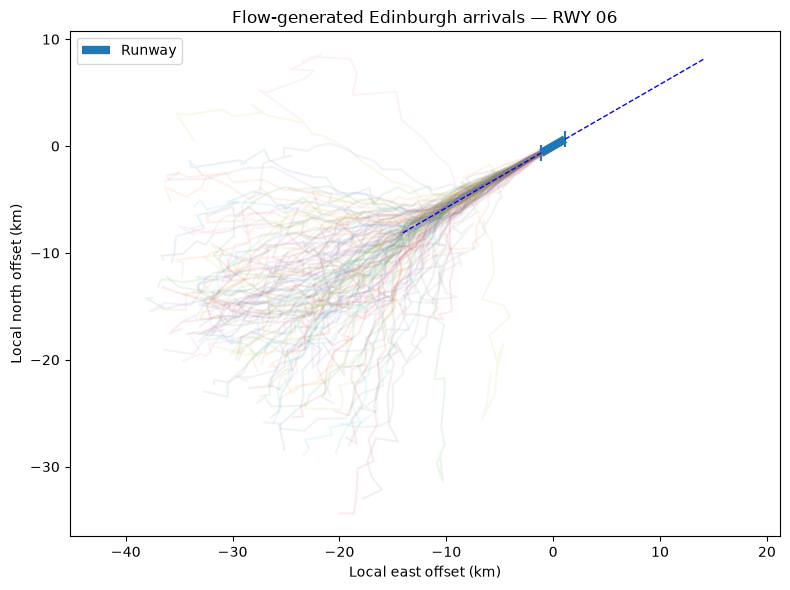

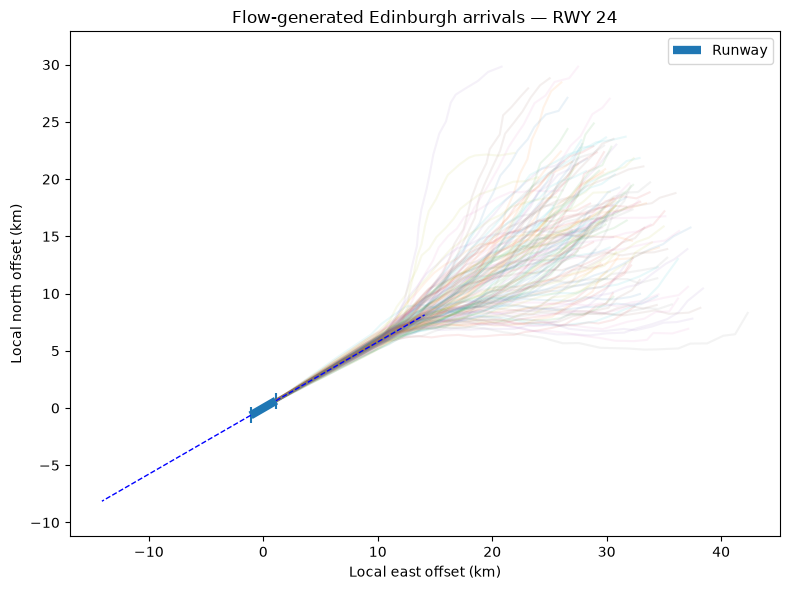

In [18]:
for generated, label in [
    (generated_06, "06"),
    (generated_24, "24"),
]:
    plt.figure(figsize=(8, 6))

    for traj in generated[:130]:
        plt.plot(traj[:, 0], traj[:, 1], alpha=0.09)

    draw_edinburgh_runway(show_extended_final=True)

    plt.xlabel("Local east offset (km)")
    plt.ylabel("Local north offset (km)")
    plt.title(f"Flow-generated Edinburgh arrivals — RWY {label}")
    plt.xlim(*AIRSPACE_XLIM)
    plt.ylim(*AIRSPACE_YLIM)
    plt.axis("equal")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 13. Compare convergence onto final approach

The flow should reproduce not only the rough map shape but also the statistical collapse of cross-track variability near the runway.


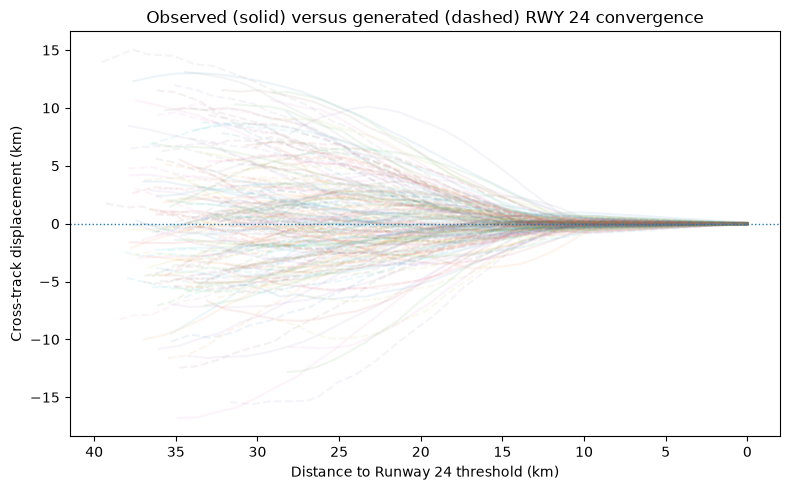

In [19]:
observed_24 = trajectories[idx_test][c_test == 1]

plt.figure(figsize=(8, 5))

for traj in observed_24[:100]:
    distance, cross = project_to_runway_coordinates(
        traj,
        runway_value=1,
    )
    plt.plot(distance, cross, alpha=0.08)

for traj in generated_24[:100]:
    distance, cross = project_to_runway_coordinates(
        traj,
        runway_value=1,
    )
    plt.plot(distance, cross, alpha=0.08, linestyle="--")

plt.axhline(0.0, linestyle=":", linewidth=1)
plt.gca().invert_xaxis()

plt.xlabel("Distance to Runway 24 threshold (km)")
plt.ylabel("Cross-track displacement (km)")
plt.title("Observed (solid) versus generated (dashed) RWY 24 convergence")
plt.tight_layout()
plt.show()


## 14. Geometric diagnostic: step length

A good density model can still generate locally awkward trajectories.

We therefore compare consecutive-waypoint distances.


Observed mean step: 1.191 km
Generated mean step: 1.207 km
Generated trajectories entirely inside plot airspace: 98.3%


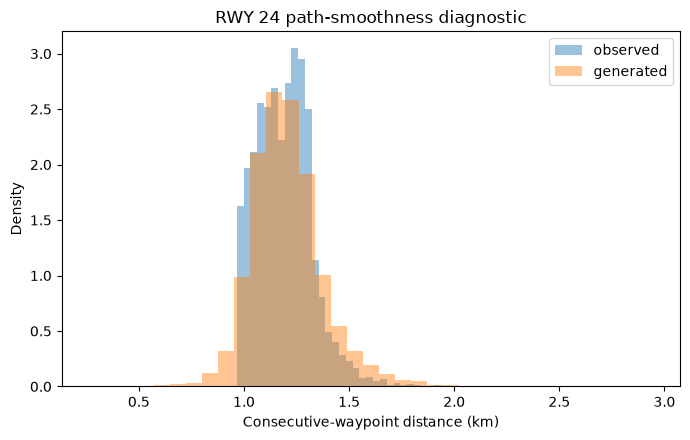

In [20]:
def step_lengths(xy):
    return torch.linalg.vector_norm(
        xy[:, 1:, :] - xy[:, :-1, :],
        dim=-1,
    )

def fraction_inside_plot_airspace(xy):
    inside = (
        (xy[:, :, 0] >= AIRSPACE_XLIM[0])
        & (xy[:, :, 0] <= AIRSPACE_XLIM[1])
        & (xy[:, :, 1] >= AIRSPACE_YLIM[0])
        & (xy[:, :, 1] <= AIRSPACE_YLIM[1])
    )

    return inside.all(dim=1).float().mean()

obs_steps = step_lengths(observed_24).flatten()
gen_steps = step_lengths(generated_24).flatten()

print("Observed mean step:", round(obs_steps.mean().item(), 3), "km")
print("Generated mean step:", round(gen_steps.mean().item(), 3), "km")
print("Generated trajectories entirely inside plot airspace:", f"{100 * fraction_inside_plot_airspace(generated_24).item():.1f}%")

plt.figure(figsize=(7, 4.5))
plt.hist(obs_steps.numpy(), bins=35, density=True, alpha=0.45, label="observed")
plt.hist(gen_steps.numpy(), bins=35, density=True, alpha=0.45, label="generated")
plt.xlabel("Consecutive-waypoint distance (km)")
plt.ylabel("Density")
plt.title("RWY 24 path-smoothness diagnostic")
plt.legend()
plt.tight_layout()
plt.show()

## 15. Same latent draw, different runway condition

Holding z fixed and changing only the runway context makes the conditioning effect visible.

This is a **model-inspection exercise**, not a causal statement about a real flight.


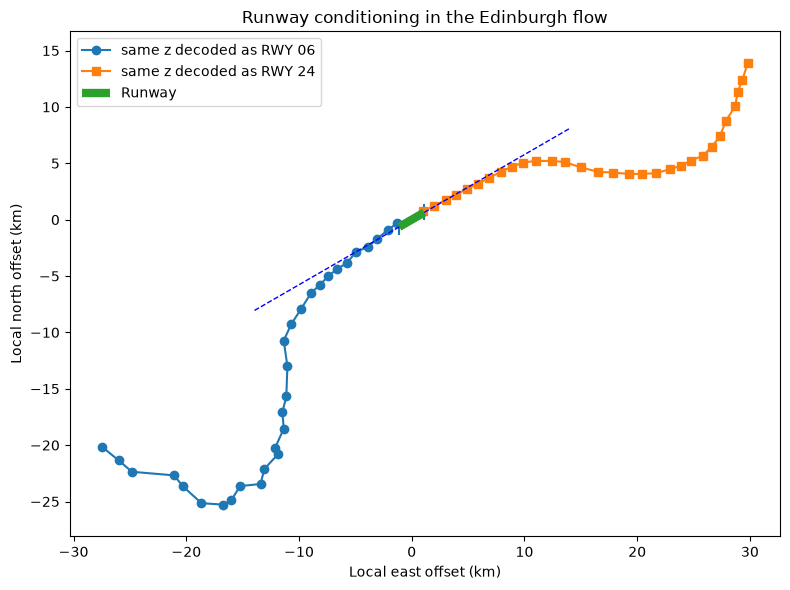

In [21]:
paired_generator = torch.Generator().manual_seed(SEED + 200)

paired_z = torch.randn(
    6,
    DIMENSION,
    generator=paired_generator,
).to(device)

condition_06 = torch.zeros(
    6,
    dtype=torch.long,
    device=device,
)

condition_24 = torch.ones(
    6,
    dtype=torch.long,
    device=device,
)

with torch.inference_mode():
    x06_std, _ = flow.inverse(
        paired_z,
        condition_06,
    )
    x24_std, _ = flow.inverse(
        paired_z,
        condition_24,
    )

x06 = unstandardise(
    x06_std.cpu()
).reshape(
    6,
    N_WAYPOINTS,
    2,
)

x24 = unstandardise(
    x24_std.cpu()
).reshape(
    6,
    N_WAYPOINTS,
    2,
)

plt.figure(figsize=(8, 6))
plt.plot(
    x06[0, :, 0],
    x06[0, :, 1],
    marker="o",
    label="same z decoded as RWY 06",
)
plt.plot(
    x24[0, :, 0],
    x24[0, :, 1],
    marker="s",
    label="same z decoded as RWY 24",
)

draw_edinburgh_runway(show_extended_final=True)

plt.xlabel("Local east offset (km)")
plt.ylabel("Local north offset (km)")
plt.title("Runway conditioning in the Edinburgh flow")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()


## 16. Save the flow and preprocessing

The standardisation statistics are required to interpret generated coordinates in kilometres, so they are stored alongside the neural-network weights.


In [22]:
checkpoint_path = Path(
    "gamex_edinburgh_arrival_realnvp.pt"
)

checkpoint = {
    "model_state_dict": flow.state_dict(),
    "model_config": {
        "dimension": DIMENSION,
        "n_layers": 12,
        "hidden_dim": 128,
        "condition_dim": 2,
        "scale_limit": 1.2,
        "shift_limit": 3.0,
    },
    "train_mean": train_mean,
    "train_std": train_std,
    "n_waypoints": N_WAYPOINTS,
    "condition_labels": {
        0: "Edinburgh Runway 06",
        1: "Edinburgh Runway 24",
    },
}

torch.save(checkpoint, checkpoint_path)

loaded = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False,
)

reloaded = EdinburghArrivalRealNVP(
    **loaded["model_config"]
).to(device)

reloaded.load_state_dict(
    loaded["model_state_dict"]
)
reloaded.eval()

with torch.inference_mode():
    z_a, ld_a = flow(
        x_test[:4].to(device),
        c_test[:4].to(device),
    )
    z_b, ld_b = reloaded(
        x_test[:4].to(device),
        c_test[:4].to(device),
    )

print(
    "Max latent difference:",
    (z_a - z_b).abs().max().item(),
)
print(
    "Max log-det difference:",
    (ld_a - ld_b).abs().max().item(),
)

assert (z_a - z_b).abs().max().item() < 1e-6


RuntimeError: Error(s) in loading state_dict for EdinburghArrivalRealNVP:
	Missing key(s) in state_dict: "layers.10.mask", "layers.10.net.0.weight", "layers.10.net.0.bias", "layers.10.net.2.weight", "layers.10.net.2.bias", "layers.10.net.4.weight", "layers.10.net.4.bias", "layers.11.mask", "layers.11.net.0.weight", "layers.11.net.0.bias", "layers.11.net.2.weight", "layers.11.net.2.bias", "layers.11.net.4.weight", "layers.11.net.4.bias". 
	size mismatch for layers.0.net.0.weight: copying a param with shape torch.Size([64, 62]) from checkpoint, the shape in current model is torch.Size([128, 62]).
	size mismatch for layers.0.net.0.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for layers.0.net.2.weight: copying a param with shape torch.Size([64, 64]) from checkpoint, the shape in current model is torch.Size([128, 128]).
	size mismatch for layers.0.net.2.bias: copying a param with shape torch.Size([64]) fro

## What fixed the poor performance?

The original implementation was not failing because affine coupling is inherently unsuitable. It was underpowered and poorly matched to the geometry of this synthetic dataset.

The important fixes were:

- **12 coupling layers instead of 6**;
- **mixed balanced masks instead of a repeated East/North split**;
- **larger, smoother conditioner networks**;
- **bounded shifts** for safer inverse sampling;
- **small training-only jitter** to regularise the almost singular trajectory density;
- **longer training with validation checkpointing**.

A key lesson is that **NLL alone is not enough for generative modelling**. An unregularised flow can over-squeeze a thin dataset, obtain an excellent likelihood and still generate poor trajectories. Always inspect both likelihood and geometric sample diagnostics.

## 17. Transformer versus normalising flow

| Transformer | Conditional RealNVP |
|---|---|
| Edinburgh airspace discretised into cells | continuous East/North coordinates |
| causal factorisation | change of variables |
| next-location cross-entropy | exact continuous NLL |
| `<RWY06>` / `<RWY24>` prefix token | runway condition enters coupling networks |
| sequential generation | one inverse-flow pass |
| easy prefix continuation | easy exact density evaluation |
| grid resolution is a modelling choice | invertibility constrains architecture |

Both models learn a **distribution of plausible arrivals toward Edinburgh's 06/24 runway**, but they represent that distribution in very different ways.
